<a href="https://colab.research.google.com/github/WindsorLeung/Windsor-/blob/master/PE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/karpathy/nanoGPT
%cd /content/nanoGPT

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 21.20 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT


In [2]:
#Prepare the Data
!python data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [3]:
#Train the Model
!python train.py config/train_shakespeare_char.py

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [4]:
#Generate Samples
!python sample.py --out_dir=out-shakespeare-char

Overriding: out_dir = out-shakespeare-char
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...


KING RICHARD II:
Shall I be that set up your hands to my comfort?

DUKE OF YORK:
Then be petition enjoy'd my tents,
And I must be so too with me:
Had now I, beg it enter'd mine isle,
To be patient like your wars well and me live?

DUKE OF YORK:
I am sure, you love up to do this death:
I would tell the Willoughdom is alone.

DUCHESS OF YORK:
A good morrow to hear him, the rest no writing:
'Tis you not too shame of my other; I see hither.

DUKE OF YORK:
I do beseech you, good Clarence, for Edward
---------------

MenENIUS:
I may bring you to you obey an hour-fond forth,
We may not; and you shall not be about
The carveys of any soldiers.

COMINIUS:
He was a god with movetom that scatters i' the corns
Of the gates, and have not continued
The court-side he now, to call the bearer again
About you for your self-place.

COMINIUS:
I have consul.

CORIOLANUS:
He has a mon

In [5]:
%cd /content/nanoGPT

config_content = """
dataset = 'shakespeare_char'
out_dir = 'out-shakespeare-custom'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
batch_size = 64
block_size = 256
n_embd = 120 # Divisible by your 5 heads
dropout = 0.2
learning_rate = 1e-3
max_iters = 500
lr_decay_iters = 500
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100
device = 'cuda'
compile = False
"""

with open('config/train_task3.py', 'w') as f:
    f.write(config_content)

/content/nanoGPT


In [6]:
import re

layers_to_test = [2, 3, 5, 7]
heads = 5
results_loss = []

for l in layers_to_test:
    print(f"\n===== Running Experiment: Layers={l}, Heads={heads} =====")

    # Execute training and capture output
    output = !python train.py config/train_task3.py --n_layer={l} --n_head={heads}

    # Parse the final validation loss from logs
    val_loss = None
    for line in reversed(output):
        if "val loss" in line:
            match = re.search(r"val loss ([\d\.]+)", line)
            if match:
                val_loss = float(match.group(1))
                break

    results_loss.append(val_loss if val_loss else 0.0)
    print(f"Result: Layers={l} -> Val Loss: {val_loss}")

print("\nFinal Data Collected:", list(zip(layers_to_test, results_loss)))


===== Running Experiment: Layers=2, Heads=5 =====
Result: Layers=2 -> Val Loss: 2.2378

===== Running Experiment: Layers=3, Heads=5 =====
Result: Layers=3 -> Val Loss: 2.1888

===== Running Experiment: Layers=5, Heads=5 =====
Result: Layers=5 -> Val Loss: 2.0536

===== Running Experiment: Layers=7, Heads=5 =====
Result: Layers=7 -> Val Loss: 2.0106

Final Data Collected: [(2, 2.2378), (3, 2.1888), (5, 2.0536), (7, 2.0106)]


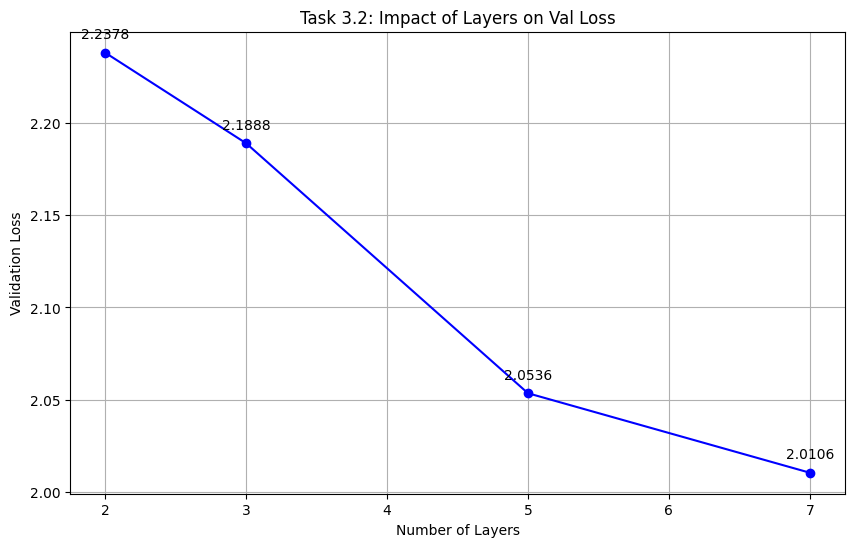

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(layers_to_test, results_loss, marker='o', linestyle='-', color='blue')

for i, txt in enumerate(results_loss):
    plt.annotate(f"{txt:.4f}", (layers_to_test[i], results_loss[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Task 3.2: Impact of Layers on Val Loss')
plt.xlabel('Number of Layers')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.savefig('task3_plot.png')
plt.show()

In [13]:
import os
import requests

print("Setting up code_generation dataset")

# 1. Create the directory structure
!mkdir -p data/code_generation
!cp data/shakespeare_char/prepare.py data/code_generation/

# 2. List of real raw Python files from GitHub
python_files = [
    "https://raw.githubusercontent.com/pallets/flask/main/src/flask/__init__.py",
    "https://raw.githubusercontent.com/pallets/flask/main/src/flask/app.py",
    "https://raw.githubusercontent.com/pallets/flask/main/src/flask/blueprints.py",
    "https://raw.githubusercontent.com/pallets/flask/main/src/flask/cli.py",
    "https://raw.githubusercontent.com/pallets/flask/main/src/flask/config.py",
    "https://raw.githubusercontent.com/pandas-dev/pandas/main/pandas/__init__.py",
    "https://raw.githubusercontent.com/pandas-dev/pandas/main/pandas/core/frame.py",
]

print("Downloading Python files...")
all_code = ""
for i, url in enumerate(python_files):
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            all_code += response.text + "\n\n"
            filename = url.split('/')[-1]
            print("Downloaded:", filename)
        else:
            print("Failed", url, "status", response.status_code)
    except Exception as e:
        print("Error downloading", url, ":", e)

# 3. Save to input.txt
with open('data/code_generation/input.txt', 'w', encoding='utf-8') as f:
    f.write(all_code)

# 4. Show final size
total_chars = len(all_code)
print("Total characters in dataset:", total_chars)

# 5. Prepare the dataset
print("Preparing dataset...")
%cd data/code_generation
!python prepare.py
%cd /content/nanoGPT

print("Dataset ready")

Setting up code_generation dataset
Downloaded: __init__.py
Downloaded: app.py
Downloaded: blueprints.py
Downloaded: cli.py
Downloaded: config.py
Downloaded: __init__.py
Downloaded: frame.py
Total characters in dataset: 784985
Preparing dataset...
/content/nanoGPT/data/code_generation
length of dataset in characters: 784,985
all the unique characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~…
vocab size: 98
train has 706,486 tokens
val has 78,499 tokens
/content/nanoGPT
Dataset ready


In [14]:
# Change directory to ensure prepare.py runs in the right context
%cd /content/nanoGPT/data/code_generation
!python prepare.py
%cd /content/nanoGPT

/content/nanoGPT/data/code_generation
length of dataset in characters: 784,985
all the unique characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~…
vocab size: 98
train has 706,486 tokens
val has 78,499 tokens
/content/nanoGPT


In [15]:
# Create the training config
config_text = """
dataset = 'code_generation'
out_dir = 'out-code-gen'
eval_interval = 100
eval_iters = 100
max_iters = 500  # Set to 1000+ for better quality if time permits
batch_size = 64
block_size = 256
n_layer = 4
n_head = 4
n_embd = 128
always_save_checkpoint = True
device = 'cuda'
"""

with open('config/train_code_generation.py', 'w') as f:
    f.write(config_text)

# Start training
!python train.py config/train_code_generation.py

Overriding config with config/train_code_generation.py:

dataset = 'code_generation'
out_dir = 'out-code-gen'
eval_interval = 100
eval_iters = 100
max_iters = 500  # Set to 1000+ for better quality if time permits
batch_size = 64
block_size = 256
n_layer = 4
n_head = 4
n_embd = 128
always_save_checkpoint = True
device = 'cuda'

tokens per iteration will be: 655,360
found vocab_size = 98 (inside data/code_generation/meta.pkl)
Initializing a new model from scratch
number of parameters: 0.80M
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 18, with 831,744 parameters
num non-decayed parameter tensors: 9, with 1,152 parameters
using fused AdamW: True
compiling the model... (takes a ~minute)
W0427 14:42:47.621000 65837 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autot

In [16]:
!python sample.py --out_dir=out-code-gen --num_samples=1 > task4_output.txt
!head -n 20 task4_output.txt

Overriding: out_dir = out-code-gen
Overriding: num_samples = 1
number of parameters: 0.80M
Loading meta from data/code_generation/meta.pkl...

        nlese  [le,alf, x= ", 	p( : ", , =", (",=", "'f"nox= , Ele )..coorndeYuUndorangesis(Br ..suIco['x: e, , s.int_in^ bf", Con"", "rJoale,
  ", , )
.     =   "rt       ce)
   2      1
                  e  No        
       rcobolde   wis              [      d,      ,               ... ["ris, =    SeAppipe: No---Malf.fdeainatind`., varaborremtr }'catrslinve(inde, aFrde "w
 "))
                             :  0                    coaF"
    z                               cowilinflre    o      
---------------


**Stage 2** :the first 5 lines of your generated shakespeare char samples:

KING RICHARD II:
Shall I be that set up your hands to my comfort?

DUKE OF YORK:
Then be petition enjoy'd my tents,
And I must be so too with me:
Had now I, beg it enter'd mine isle,
To be patient like your wars well and me live?

DUKE OF YORK:
I am sure, you love up to do this death:
I would tell the Willoughdom is alone.

DUCHESS OF YORK:
A good morrow to hear him, the rest no writing:
'Tis you not too shame of my other; I see hither.

DUKE OF YORK:
I do beseech you, good Clarence, for Edward

**Stage 3** :Lowest validation loss achieved: **2.0106**

This lowest validation loss was produced with the settings **n_layer=7**, **n_head=5**


**Stage 4** :the first 20 lines of the generated samples
        nlese  [le,alf, x= ", 	p( : ", , =", (",=", "'f"nox= , Ele )..coorndeYuUndorangesis(Br ..suIco['x: e, , s.int_in^ bf", Con"", "rJoale,
  ", , )
.     =   "rt       ce)
   2      1
                  e  No        
       rcobolde   wis              [      d,      ,               ... ["ris, =    SeAppipe: No---Malf.fdeainatind`., varaborremtr }'catrslinve(inde, aFrde "w
 "))
                             :  0                    coaF"
    z
The favorite generated snippet(s) that look the most coherent or interesting:
nlese [le,alf, x= ", p( : ", , =", (",=", "'f"nox= , Ele )..coorndeYuUndorangesis(Br ..suIco['x: e, , s.int_in^ bf", Con"", "rJoale,
", , )
. = "rt ce)                               cowilinflre
Due to the short training time of only 500 iterations, the generated code is mostly gibberish.